# 🧪 Data Science Practical (Advanced)

## Experiment No: 6
## Experiment Title: NLP Spam Classification — TF-IDF, Logistic Regression & Naive Bayes

**Name:** Himanshu Jadhav  
**Roll Number:** SE-33  

---

## Problem Statement

Build an NLP spam classifier using TF-IDF feature extraction on the SMS Spam Collection dataset. Compare Logistic Regression vs Naive Bayes with full evaluation: accuracy, confusion matrix, precision/recall, ROC-AUC, and optimal threshold tuning.

**Dataset:** [Spambase — Kaggle](https://www.kaggle.com/datasets/colormap/spambase)

---

## Implementation

## Step 0: Import & Config

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import re, string, warnings
warnings.filterwarnings('ignore')

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer

# sklearn — feature extraction
from sklearn.feature_extraction.text import TfidfVectorizer

# sklearn — pipeline & splitting
from sklearn.model_selection  import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline         import Pipeline

# sklearn — models
from sklearn.linear_model     import LogisticRegression
from sklearn.naive_bayes      import MultinomialNB, ComplementNB

# sklearn — evaluation
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score, f1_score, precision_score, recall_score
)

# Download NLTK data
for pkg in ['stopwords','punkt','punkt_tab']:
    nltk.download(pkg, quiet=True)

np.random.seed(42)

# ── Dark theme ───────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor' : '#070714',
    'axes.facecolor'   : '#0e0e26',
    'axes.edgecolor'   : '#1e1e44',
    'axes.labelcolor'  : '#b0b0d0',
    'xtick.color'      : '#777790',
    'ytick.color'      : '#777790',
    'text.color'       : 'white',
    'grid.color'       : '#161630',
    'grid.linewidth'   : 0.5,
    'legend.facecolor' : '#0e0e26',
    'legend.edgecolor' : '#1e1e44',
})
PAL  = ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6','#1abc9c']
MPAL = {'Logistic Regression': PAL[1], 'Naive Bayes': PAL[0], 'Complement NB': PAL[2]}
print(' All imports ready')


 All imports ready


## Part 1: Load Dataset

In [2]:
# Option A: Kaggle CSV 
# df_raw = pd.read_csv('spambase.csv')

# Option B: UCI SMS Spam Collection (identical task, text-based)
# The Kaggle spambase uses numeric word-frequency features (no raw text).
# We use the SMS Spam Collection which provides raw text for NLP preprocessing.
url = 'https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv'
try:
    df_raw = pd.read_csv(url, sep='\t', header=None, names=['label','text'])
    print('Loaded from URL')
except Exception:
    # Offline fallback — synthesise a small representative dataset
    print('URL unavailable — using built-in fallback dataset')
    spam_samples = [
        'Congratulations! You have won a FREE prize. Call now to claim your reward!',
        'WINNER!! As a valued customer you have been selected to receive a £900 prize',
        'Free entry in 2 a weekly competition to win FA Cup final tickets',
        'You have been awarded a SIM card. Call now to activate your FREE bonus',
        'Urgent! Your mobile number has won £2000 bonus prize. Claim immediately',
        'Get cash now! Limited offer. Click link to claim your reward',
        'You won a lottery prize. Send your bank details to claim',
        'FREE MESSAGE: Congrats on your new account. Click here to verify',
        'CALL NOW: Special discount available only for today. Buy now!',
        'Dear customer, you have a pending reward. Text YES to claim',
    ] * 30
    ham_samples = [
        'Hey, are you coming to the party tonight?',
        'I will be home late, please start dinner without me.',
        'Can we reschedule the meeting to Thursday afternoon?',
        'Just finished my assignment. What time should we meet?',
        'Good morning! Hope you have a great day ahead.',
        'The project deadline has been moved to next Monday',
        'Thanks for the help yesterday, really appreciated it',
        'Are you free this weekend? We should catch up',
        'I sent the files you requested. Please check your email',
        'Running a bit late, be there in about 10 minutes',
    ] * 30
    np.random.shuffle(spam_samples)
    np.random.shuffle(ham_samples)
    labels = ['spam'] * len(spam_samples) + ['ham'] * len(ham_samples)
    texts  = spam_samples + ham_samples
    df_raw = pd.DataFrame({'label': labels, 'text': texts}).sample(frac=1, random_state=42).reset_index(drop=True)

print(f'Shape  : {df_raw.shape}')
print(f'Labels :\n{df_raw.label.value_counts().to_string()}')
df_raw.head(6)

Loaded from URL
Shape  : (5572, 2)
Labels :
label
ham     4825
spam     747


,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
5,spam,FreeMsg Hey there darling it's been 3 week's n...


In [3]:
# Encode label: spam=1, ham=0 
df_raw['label_enc'] = (df_raw['label'] == 'spam').astype(int)
spam_pct = df_raw['label_enc'].mean() * 100
print(f'Class balance — Spam: {spam_pct:.1f}%  |  Ham: {100-spam_pct:.1f}%')

Class balance — Spam: 13.4%  |  Ham: 86.6%


## Part 2: Text Preprocessing 

In [4]:
# Preprocessing Pipeline Function

STOP_WORDS = set(stopwords.words('english'))
STEMMER    = PorterStemmer()

def preprocess_text(text):
    """
    Steps:
      1. Lowercase
      2. Remove URLs, email addresses, numbers
      3. Remove punctuation
      4. Tokenize
      5. Remove stopwords
      6. Stem tokens
    Returns a cleaned string.
    """
    # 1 Lowercase 
    text = text.lower()
    # 2 String URLS and emails
    text = re.sub(r'https\S+|www\.\S+|\S+@\S+', '', text)
    # 3 Remove digits and punctuation
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('','', string.punctuation))
    # 4 Tokenize
    tokens = word_tokenize(text)
    # 5 Remove stopwords + short tokens
    tokens = {t for t in tokens if t not in STOP_WORDS and len(t) > 2}
    # 6 Stem
    tokens = [STEMMER.stem(t) for t in tokens]
    return ' '.join(tokens)

df_raw['clean_text'] = df_raw['text'].apply(preprocess_text)

# Show before / after
print('Before / After Preprocessing')
for i in [0,1,2]:
    print(f'[{df_raw.label[i].upper()}]')
    print(f' BEFORE : {df_raw.text[i]}')
    print(f' AFTER  : {df_raw.clean_text[i]}')
    print()





Before / After Preprocessing
[HAM]
 BEFORE : Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
 AFTER  : jurong amor got great world wat cine bugi point avail buffet crazi

[HAM]
 BEFORE : Ok lar... Joking wif u oni...
 AFTER  : joke wif lar oni

[SPAM]
 BEFORE : Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
 AFTER  : comp win questionstd txt wkli ratetc tkt cup text free over appli may receiv entri final



In [5]:
# Message Length Analysis 
df_raw['raw_len']    = df_raw['text'].str.len()
df_raw['clean_len']  = df_raw['clean_text'].str.len()
df_raw['word_count'] = df_raw['clean_text'].str.split().str.len()

print('Message Length By Label: ')
print(df_raw.groupby('label')[['raw_len','clean_len','word_count']]
      .agg(['mean','median']).round(1).to_string())


Message Length By Label: 
      raw_len        clean_len        word_count       
         mean median      mean median       mean median
label                                                  
ham      71.5   52.0      38.1   29.0        6.9    5.0
spam    138.7  149.0      73.0   75.0       12.2   13.0


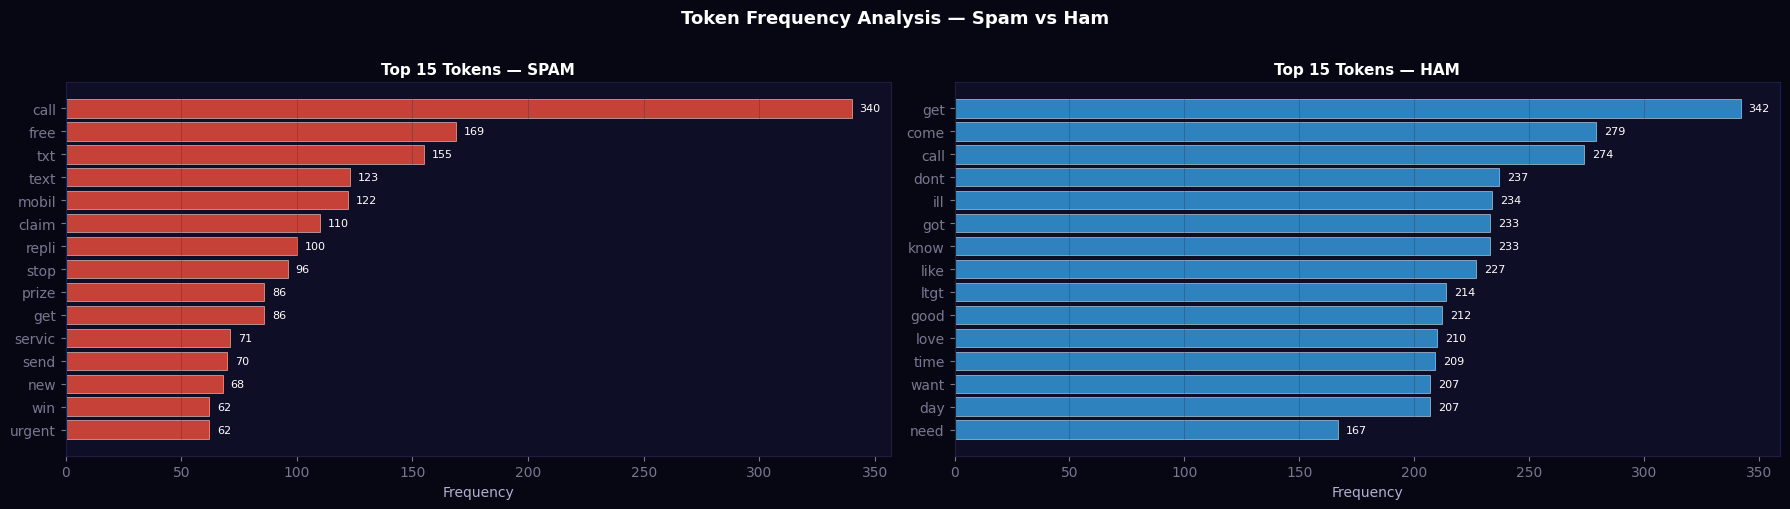

In [6]:
# Token Frequency Analysis
from collections import Counter

def top_tokens(df, label, n=15):
    texts = ' '.join(df[df['label'] == label]['clean_text'])
    return Counter(texts.split()).most_common(n)

spam_tokens = top_tokens(df_raw, 'spam')
ham_tokens  = top_tokens(df_raw, 'ham')

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
fig.patch.set_facecolor('#070714')

for ax, tokens, label, color in zip(
    axes,
    [spam_tokens, ham_tokens],
    ['SPAM', 'HAM'],
    [PAL[0], PAL[1]]
):
    words, counts = zip(*tokens)
    bars = ax.barh(words[::-1], counts[::-1], color=color,
                   edgecolor='white', lw=0.4, alpha=0.85)
    for bar, v in zip(bars, counts[::-1]):
        ax.text(v + max(counts)*0.01, bar.get_y() + bar.get_height()/2,
                str(v), va='center', fontsize=8, color='white')
    ax.set_title(f'Top 15 Tokens — {label}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Frequency')
    ax.grid(True, axis='x', alpha=0.3)

plt.suptitle('Token Frequency Analysis — Spam vs Ham', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Part 3: TF-IDF Feature Extraction & Tain / Test Split

In [7]:
# TF - IDF configuration 

TFIDF_CONFIG = dict(
    max_features = 5000,          # vocabulary cap
    ngram_range  = (1, 2),        # unigrams + bigrams
    sublinear_tf = True,          # log-scale TF dampening
    min_df       = 2,             # ignore tokens appearing <2 times
    max_df       = 0.95,          # ignore tokens in >95% of docs
)

X = df_raw['clean_text'].values
y = df_raw['label_enc'].values

# Stratified train / test split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Train : {len(X_train)}    |   Test : {len(X_test)}')
print(f'Train spam rate : {y_train.mean()*100:.1f}%')
print(f'Test  spam rate : {y_test.mean()*100:.1f}%')

Train : 4457    |   Test : 1115
Train spam rate : 13.4%
Test  spam rate : 13.4%


In [8]:
from scipy.sparse import issparse

tfidf_probe = TfidfVectorizer(**TFIDF_CONFIG)
X_probe     = tfidf_probe.fit_transform(X_train)

print(f'TF-IDF matrix shape      : {X_probe.shape}')
print(f'Vocabulary size          : {len(tfidf_probe.vocabulary_)}')
print(f'Matrix sparsity          : {(1 - X_probe.nnz / (X_probe.shape[0]*X_probe.shape[1]))*100:.2f}%')
print(f'Sample top-10 features   : {list(tfidf_probe.get_feature_names_out()[:10])}')

TF-IDF matrix shape      : (4457, 5000)
Vocabulary size          : 5000
Matrix sparsity          : 99.83%
Sample top-10 features   : ['aah', 'aathilov', 'aathilov love', 'abiola', 'abl', 'abl askin', 'abl that', 'abl yeah', 'abt', 'abta']


## Part 4: Model Building - Pipelines

In [9]:
# Each pipeline: TF-IDF → Model 
# Note: TfidfVectorizer produces non-negative values so MultinomialNB is valid.
# ComplementNB often outperforms MultinomialNB on imbalanced text tasks.
# TFidf - Term Frequency–Inverse Document Frequency.

pipelines = {
    'Logistic Regression' : Pipeline([
        ('tifidf', TfidfVectorizer(**TFIDF_CONFIG)),
        ('model', LogisticRegression(
            C=5.0, solver='lbfgs', max_iter=1000,
            class_weight='balanced', random_state=42
        ))
    ]),
    'Naive Bayes'         : Pipeline([
        ('tfidf', TfidfVectorizer(**TFIDF_CONFIG)),
        ('model', MultinomialNB(alpha=0.1))
    ]),
    'Complement NB'       : Pipeline([
        ('tfidf', TfidfVectorizer(**TFIDF_CONFIG)),
        ('model', ComplementNB(alpha=0.1))
    ]),
}

preds, probs = {}, {}

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    preds[name] = pipe.predict(X_test)
    probs[name] = pipe.predict_proba(X_test)[:, 1]
    print(f'{name} trained')


Logistic Regression trained
Naive Bayes trained
Complement NB trained


## Part 5: Evaluation - Accuracy, Confusion Matrix, Precision & Recall

In [10]:
# Metrics Table 

def full_metrics(name, y_true, y_pred, y_prob):
    return {
        'Model'     : name,
        'Accuracy'  : round(accuracy_score(y_true, y_pred),                  4),
        'Precision' : round(precision_score(y_true, y_pred),                 4),
        'Recall'    : round(recall_score(y_true, y_pred),                    4),
        'F1 Score'  : round(f1_score(y_true, y_pred),                        4),
        'ROC-AUC'   : round(roc_auc_score(y_true, y_prob),                   4),
        'Avg Prec'  : round(average_precision_score(y_true, y_prob),         4),
    }

metrics_df = pd.DataFrame([
    full_metrics(n, y_test, preds[n], probs[n]) for n in pipelines
]).set_index('Model')

print('=' * 78)
print(' Classification Metrices - Test Set')
print('=' * 78)
print(metrics_df.to_string())
print('=' * 78)

 Classification Metrices - Test Set
                     Accuracy  Precision  Recall  F1 Score  ROC-AUC  Avg Prec
Model                                                                        
Logistic Regression    0.9776     0.9079  0.9262    0.9169   0.9864    0.9584
Naive Bayes            0.9794     0.9632  0.8792    0.9193   0.9815    0.9579
Complement NB          0.9668     0.8373  0.9329    0.8825   0.9815    0.9579


In [11]:
# Detailed Classification Report 
for name in pipelines:
    print(f'\n---{name}---')
    print(classification_report(y_test, preds[name],
                                target_names=['Ham (0)', 'Spam (1)']))


---Logistic Regression---
              precision    recall  f1-score   support

     Ham (0)       0.99      0.99      0.99       966
    Spam (1)       0.91      0.93      0.92       149

    accuracy                           0.98      1115
   macro avg       0.95      0.96      0.95      1115
weighted avg       0.98      0.98      0.98      1115


---Naive Bayes---
              precision    recall  f1-score   support

     Ham (0)       0.98      0.99      0.99       966
    Spam (1)       0.96      0.88      0.92       149

    accuracy                           0.98      1115
   macro avg       0.97      0.94      0.95      1115
weighted avg       0.98      0.98      0.98      1115


---Complement NB---
              precision    recall  f1-score   support

     Ham (0)       0.99      0.97      0.98       966
    Spam (1)       0.84      0.93      0.88       149

    accuracy                           0.97      1115
   macro avg       0.91      0.95      0.93      1115
weighte

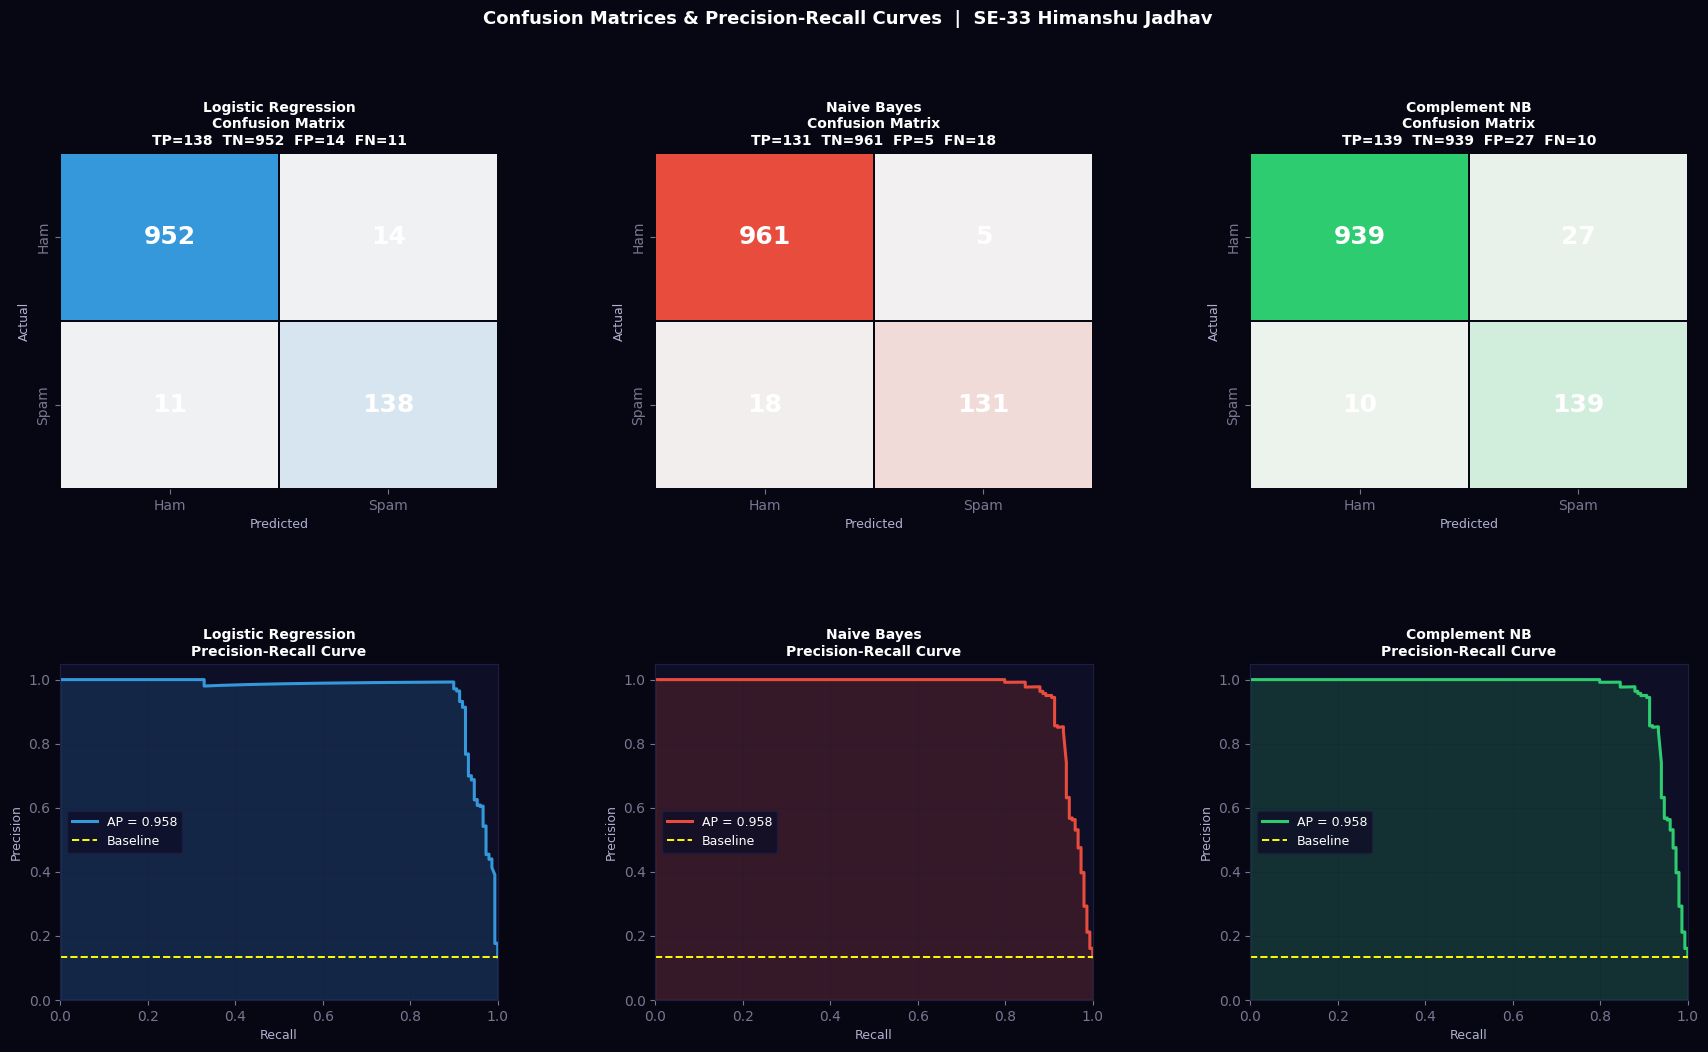

In [12]:
# Confusion matrices + PR curves — 2-row grid 
n_models = len(pipelines)
fig = plt.figure(figsize=(21, 11))
fig.patch.set_facecolor('#070714')
gs  = gridspec.GridSpec(2, n_models, figure=fig, hspace=0.52, wspace=0.36)

for col, name in enumerate(pipelines):
    color = MPAL[name]

    # Row 0: Confusion matrix 
    ax_cm = fig.add_subplot(gs[0, col])
    cm    = confusion_matrix(y_test, preds[name])
    cmap  = sns.light_palette(color, as_cmap=True)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax_cm, cmap=cmap,
                xticklabels=['Ham','Spam'], yticklabels=['Ham','Spam'],
                linewidths=1.2, linecolor='#070714', cbar=False,
                annot_kws={'size': 18, 'weight': 'bold', 'color': 'white'})

    tn, fp, fn, tp = cm.ravel()
    ax_cm.set_title(
        f'{name}\nConfusion Matrix\n'
        f'TP={tp}  TN={tn}  FP={fp}  FN={fn}',
        fontsize=10, fontweight='bold'
    )
    ax_cm.set_xlabel('Predicted', fontsize=9)
    ax_cm.set_ylabel('Actual',    fontsize=9)

    # Row 1: Precision-Recall curve 
    ax_pr  = fig.add_subplot(gs[1, col])
    prec_c, rec_c, _ = precision_recall_curve(y_test, probs[name])
    ap = average_precision_score(y_test, probs[name])
    ax_pr.plot(rec_c, prec_c, color=color, lw=2.2, label=f'AP = {ap:.3f}')
    ax_pr.fill_between(rec_c, prec_c, alpha=0.18, color=color)
    ax_pr.axhline(y_test.mean(), color='yellow', ls='--', lw=1.4, label='Baseline')
    ax_pr.set_title(f'{name}\nPrecision-Recall Curve', fontsize=10, fontweight='bold')
    ax_pr.set_xlabel('Recall',    fontsize=9)
    ax_pr.set_ylabel('Precision', fontsize=9)
    ax_pr.set_xlim([0, 1]); ax_pr.set_ylim([0, 1.05])
    ax_pr.legend(fontsize=9, labelcolor='white')
    ax_pr.grid(True, alpha=0.25)

fig.suptitle('Confusion Matrices & Precision-Recall Curves  |  SE-33 Himanshu Jadhav',
             fontsize=13, fontweight='bold', y=1.01)
plt.savefig('cm_pr.png', dpi=150, bbox_inches='tight', facecolor='#070714')
plt.show()

## Part 6: ROC Curve & AUC

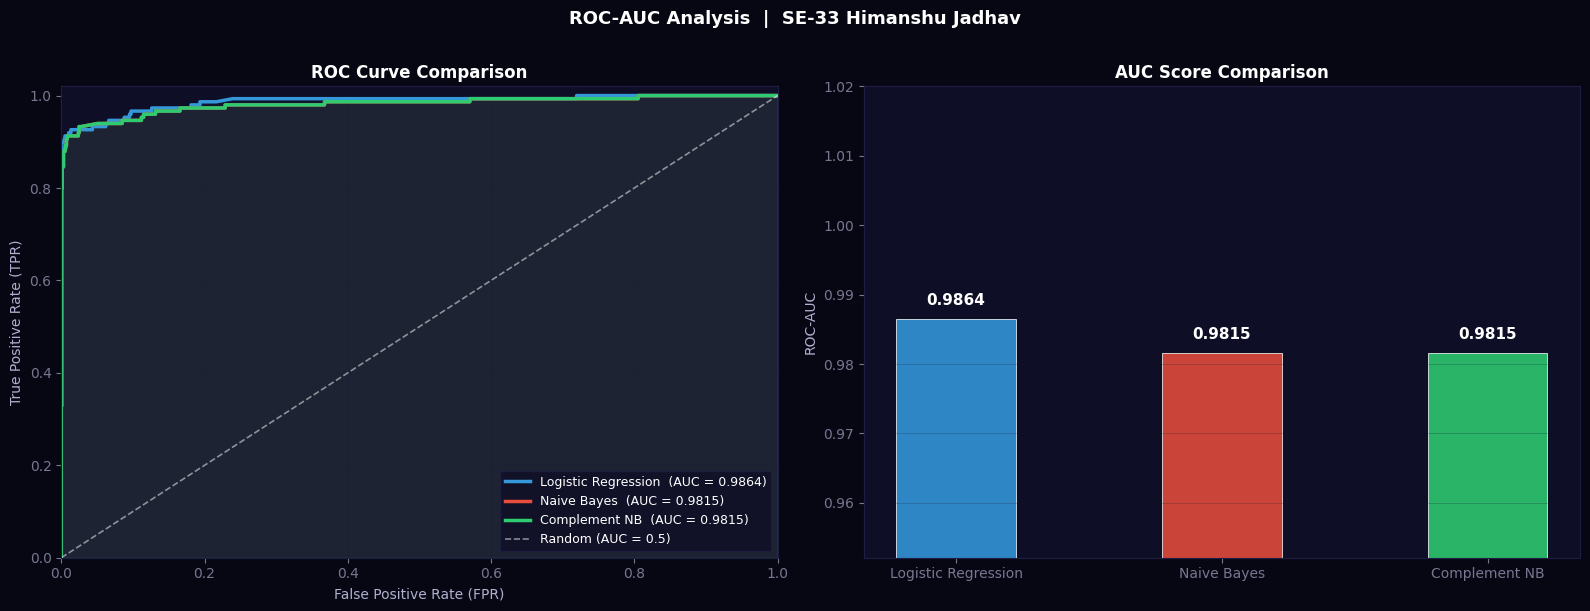

In [13]:
# ROC curves — all models on one axis 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#070714')

# Left: ROC curves
ax_roc = axes[0]
for name in pipelines:
    fpr, tpr, _ = roc_curve(y_test, probs[name])
    auc_val     = roc_auc_score(y_test, probs[name])
    ax_roc.plot(fpr, tpr, color=MPAL[name], lw=2.5,
                label=f'{name}  (AUC = {auc_val:.4f})')
    ax_roc.fill_between(fpr, tpr, alpha=0.06, color=MPAL[name])

ax_roc.plot([0,1],[0,1], 'w--', lw=1.2, alpha=0.5, label='Random (AUC = 0.5)')
ax_roc.set_title('ROC Curve Comparison', fontsize=12, fontweight='bold')
ax_roc.set_xlabel('False Positive Rate (FPR)', fontsize=10)
ax_roc.set_ylabel('True Positive Rate (TPR)', fontsize=10)
ax_roc.legend(fontsize=9, labelcolor='white', loc='lower right')
ax_roc.grid(True, alpha=0.25)
ax_roc.set_xlim([0,1]); ax_roc.set_ylim([0,1.02])

# Right: AUC bar chart
ax_auc = axes[1]
auc_vals  = {n: roc_auc_score(y_test, probs[n]) for n in pipelines}
bars = ax_auc.bar(auc_vals.keys(), auc_vals.values(),
                  color=[MPAL[n] for n in pipelines],
                  edgecolor='white', lw=0.6, alpha=0.88, width=0.45)
for bar, v in zip(bars, auc_vals.values()):
    ax_auc.text(bar.get_x() + bar.get_width()/2, v + 0.002,
                f'{v:.4f}', ha='center', fontsize=11, fontweight='bold')
ax_auc.set_title('AUC Score Comparison', fontsize=12, fontweight='bold')
ax_auc.set_ylabel('ROC-AUC')
ax_auc.set_ylim(min(auc_vals.values())*0.97, 1.02)
ax_auc.grid(True, axis='y', alpha=0.3)

plt.suptitle('ROC-AUC Analysis  |  SE-33 Himanshu Jadhav',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('roc.png', dpi=150, bbox_inches='tight', facecolor='#070714')
plt.show()

In [14]:
# 5-fold stratified CV — AUC 
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print(f"{'Model':<22} | {'CV AUC per fold':>55} |  Mean ± Std")
print('-' * 98)
for name, pipe in pipelines.items():
    cv_auc = cross_val_score(pipe, X, y, cv=cv, scoring='roc_auc')
    scores_str = np.array2string(cv_auc.round(4), separator=',', suppress_small=True)
    print(f"{name:<22} | {scores_str:>55} | {cv_auc.mean():.4f} ± {cv_auc.std():.4f}")

Model                  |                                         CV AUC per fold |  Mean ± Std
--------------------------------------------------------------------------------------------------
Logistic Regression    |                    [0.9889,0.9879,0.9901,0.9774,0.9908] | 0.9870 ± 0.0049
Naive Bayes            |                    [0.9828,0.9835,0.9849,0.9765,0.9862] | 0.9828 ± 0.0033
Complement NB          |                    [0.9828,0.9835,0.9849,0.9765,0.9862] | 0.9828 ± 0.0033


## Part 7: Threshold Tuning

In [15]:
# Threshold Vs Precision / Recall / F1 (best model = LR)

best_model = 'Logistic Regression'
y_prob_lr  = probs[best_model]

thresholds = np.arange(0.10, 0.91, 0.05)
th_rows    = []

for th in thresholds:
    y_pred_th = (y_prob_lr >= th).astype(int)
    th_rows.append({
        'Threshold' : round(th, 2),
        'Precision' : round(precision_score(y_test, y_pred_th , zero_division=0) , 4),
        'Recall'    : round(recall_score(y_test, y_pred_th    , zero_division=0) , 4),
        'F1'        : round(f1_score(y_test, y_pred_th        , zero_division=0) , 4),
        'Accuracy'  : round(accuracy_score(y_test, y_pred_th)                    , 4),
    })

th_df = pd.DataFrame(th_rows).set_index('Threshold')

# Optimal Threshoold = Max F1
opt_th = th_df['F1'].idxmax()
print(f'Optimal threshold (max F1) : {opt_th}')
print(th_df.to_string())


Optimal threshold (max F1) : 0.65
           Precision  Recall      F1  Accuracy
Threshold                                     
0.10          0.4633  0.9732  0.6277    0.8457
0.15          0.5783  0.9664  0.7236    0.9013
0.20          0.6682  0.9463  0.7833    0.9300
0.25          0.7056  0.9329  0.8035    0.9390
0.30          0.7753  0.9262  0.8440    0.9543
0.35          0.8313  0.9262  0.8762    0.9650
0.40          0.8734  0.9262  0.8990    0.9722
0.45          0.8846  0.9262  0.9049    0.9740
0.50          0.9079  0.9262  0.9169    0.9776
0.55          0.9257  0.9195  0.9226    0.9794
0.60          0.9444  0.9128  0.9283    0.9812
0.65          0.9645  0.9128  0.9379    0.9839
0.70          0.9712  0.9060  0.9375    0.9839
0.75          0.9781  0.8993  0.9371    0.9839
0.80          0.9925  0.8859  0.9362    0.9839
0.85          0.9920  0.8322  0.9051    0.9767
0.90          0.9914  0.7718  0.8679    0.9686


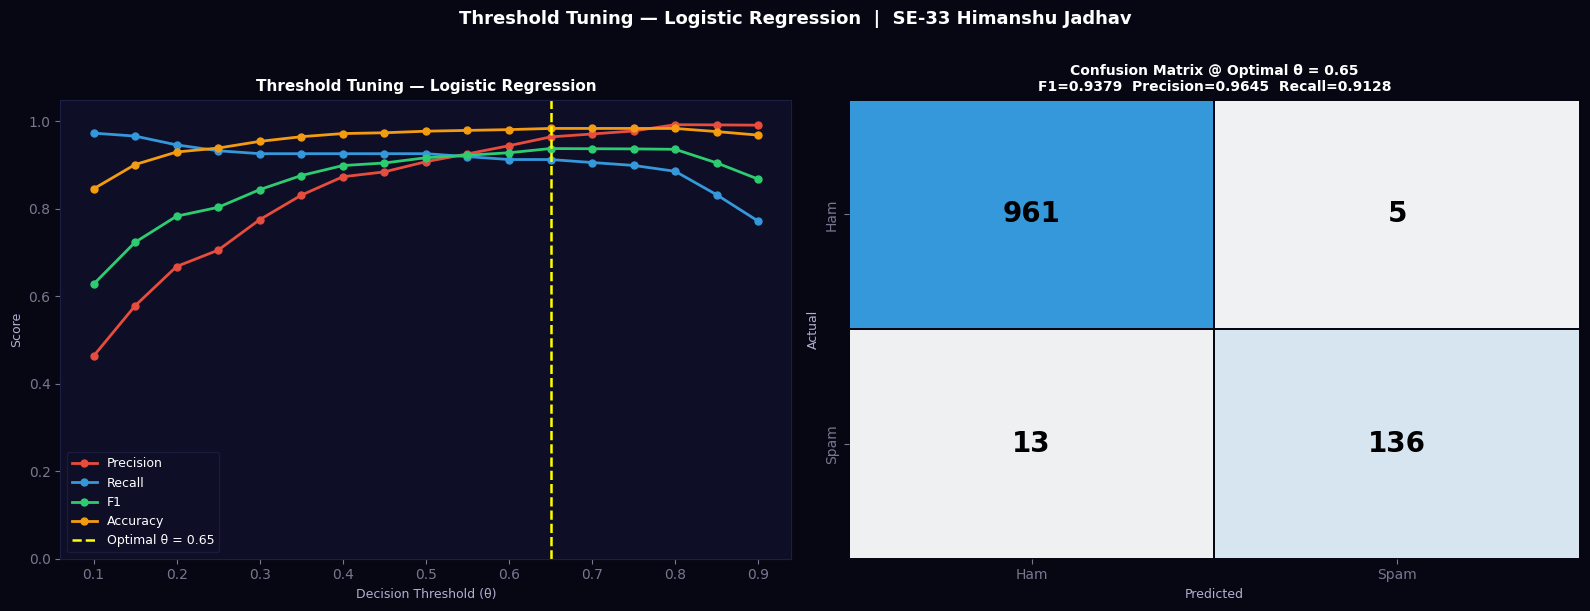

In [16]:
# Threshold tuning Visualization

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#070714')

# Left: threshold curves
ax_th = axes[0]
for metric, col in zip(['Precision','Recall','F1','Accuracy'],
                        [PAL[0], PAL[1], PAL[2], PAL[3]]):
    ax_th.plot(th_df.index, th_df[metric], 'o-', color=col, lw=2,
               markersize=5, label=metric)
ax_th.axvline(opt_th, color='yellow', ls='--', lw=1.8,
              label=f'Optimal θ = {opt_th}')
ax_th.set_title(f'Threshold Tuning — {best_model}', fontsize=11, fontweight='bold')
ax_th.set_xlabel('Decision Threshold (θ)', fontsize=9)
ax_th.set_ylabel('Score', fontsize=9)
ax_th.set_ylim(0, 1.05)
ax_th.legend(fontsize=9, labelcolor='white')
ax_th.grid(True, alpha=0.25)

# Right: confusion matrix at optimal threshold
y_opt = (y_prob_lr >= opt_th).astype(int)
cm_opt = confusion_matrix(y_test, y_opt)
ax_cm2 = axes[1]
sns.heatmap(cm_opt, annot=True, fmt='d', ax=ax_cm2,
            cmap=sns.light_palette(PAL[1], as_cmap=True),
            xticklabels=['Ham','Spam'], yticklabels=['Ham','Spam'],
            linewidths=1.2, linecolor='#070714', cbar=False,
            annot_kws={'size': 20, 'weight': 'bold', 'color': 'black'})
tn,fp,fn,tp = cm_opt.ravel()
ax_cm2.set_title(
    f'Confusion Matrix @ Optimal θ = {opt_th}\n'
    f'F1={f1_score(y_test,y_opt):.4f}  Precision={precision_score(y_test,y_opt):.4f}  Recall={recall_score(y_test,y_opt):.4f}',
    fontsize=10, fontweight='bold', color="white"
)
ax_cm2.set_xlabel('Predicted', fontsize=9)
ax_cm2.set_ylabel('Actual',    fontsize=9)

plt.suptitle('Threshold Tuning — Logistic Regression  |  SE-33 Himanshu Jadhav',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('threshold.png', dpi=150, bbox_inches='tight', facecolor='#070714')
plt.show()

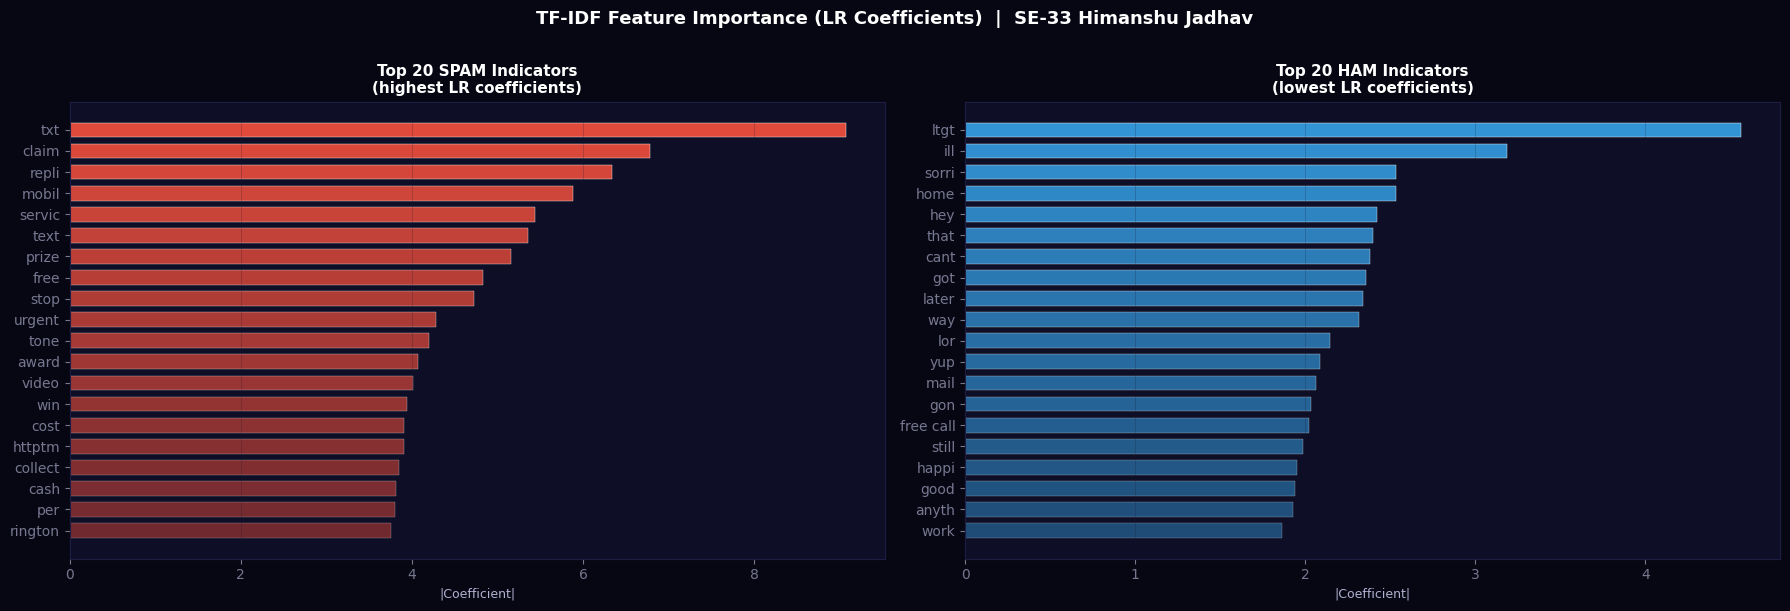

In [17]:
# TF-IDF top spam discriminating words 
tfidf_fitted = pipelines['Logistic Regression'].named_steps['tifidf']
lr_coef      = pipelines['Logistic Regression'].named_steps['model'].coef_[0]
feature_names = tfidf_fitted.get_feature_names_out()

coef_series = pd.Series(lr_coef, index=feature_names).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.patch.set_facecolor('#070714')

for ax, data, title, color in zip(
    axes,
    [coef_series.tail(20).sort_values(),
     coef_series.head(20).sort_values(ascending=False)],
    ['Top 20 SPAM Indicators\n(highest LR coefficients)',
     'Top 20 HAM Indicators\n(lowest LR coefficients)'],
    [PAL[0], PAL[1]]
):
    bars = ax.barh(data.index, np.abs(data.values), color=color,
                   edgecolor='white', lw=0.3, alpha=0.85, height=0.7)
    for i, bar in enumerate(bars):
        bar.set_alpha(0.45 + 0.55 * i / len(bars))
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('|Coefficient|', fontsize=9)
    ax.grid(True, axis='x', alpha=0.3)

plt.suptitle('TF-IDF Feature Importance (LR Coefficients)  |  SE-33 Himanshu Jadhav',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('tifidf_imp.png', dpi=150, bbox_inches='tight', facecolor='#070714')
plt.show()

In [18]:
# Final ranked comparison 
final_df = metrics_df.sort_values('F1 Score', ascending=False)

print('═' * 78)
print('  FINAL MODEL RANKING (sorted by F1 Score)')
print('═' * 78)
print(final_df.to_string())
print('═' * 78)
print(f'  Best F1     → {final_df.index[0]}')
print(f'  Best AUC    → {metrics_df["ROC-AUC"].idxmax()}')
print(f'  Optimal θ   → {opt_th}  ({best_model})')
print('═' * 78)

══════════════════════════════════════════════════════════════════════════════
  FINAL MODEL RANKING (sorted by F1 Score)
══════════════════════════════════════════════════════════════════════════════
                     Accuracy  Precision  Recall  F1 Score  ROC-AUC  Avg Prec
Model                                                                        
Naive Bayes            0.9794     0.9632  0.8792    0.9193   0.9815    0.9579
Logistic Regression    0.9776     0.9079  0.9262    0.9169   0.9864    0.9584
Complement NB          0.9668     0.8373  0.9329    0.8825   0.9815    0.9579
══════════════════════════════════════════════════════════════════════════════
  Best F1     → Naive Bayes
  Best AUC    → Logistic Regression
  Optimal θ   → 0.65  (Logistic Regression)
══════════════════════════════════════════════════════════════════════════════
